# K-Means Clustering & Algorithm Comparison

**Goal:** Cluster NYC FHV pickup locations using K-Means on the same feature space as DBSCAN, then produce a quantitative side-by-side comparison.

**Data source:** `../Data/raw/merged_trip_emissions_coordinates.csv`  \n

**Features used for clustering:**
- `pickup_lat`, `pickup_lon` — geographic position
- `hour_sin`, `hour_cos` — cyclic encoding of pickup hour

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

In [3]:
DATA_PATH = "../Data/raw/merged_trip_emissions_coordinates.csv"
SUBSET_N  = 10000

df_full = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset : {len(df_full):,} rows")

def preprocess(df):
    df = df.copy()

    # Coerce types
    df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
    df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
    df["pickup_lat"]       = pd.to_numeric(df["pickup_lat"],        errors="coerce")
    df["pickup_lon"]       = pd.to_numeric(df["pickup_lon"],        errors="coerce")
    df["trip_miles"]       = pd.to_numeric(df["trip_miles"],        errors="coerce")
    df["co2TailpipeGpm"]   = pd.to_numeric(df["co2TailpipeGpm"],    errors="coerce")
    df["co2_total_g"]      = pd.to_numeric(df["co2_total_g"],       errors="coerce")

    df = df.dropna(subset=["pickup_lat", "pickup_lon", "pickup_datetime", "PULocationID"])

    df[["pickup_lat", "pickup_lon", "trip_miles", "co2TailpipeGpm", "co2_total_g"]].describe().round(3)
    print(f"Working subset after cleaning: {len(df):,} rows")

    # Time features
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)

    return df

# Reproducible sample
df_train = preprocess(df_full.sample(n = SUBSET_N, random_state = RANDOM_STATE).reset_index(drop=True))


Full dataset : 2,062,185 rows
Working subset after cleaning: 10,000 rows


## Feature Engineering

In [4]:
df_train["pickup_hour"] = df_train["pickup_datetime"].dt.hour

df_train["hour_sin"] = np.sin(2 * np.pi * df_train["pickup_hour"] / 24)
df_train["hour_cos"] = np.cos(2 * np.pi * df_train["pickup_hour"] / 24)

features = ["pickup_lat", "pickup_lon", "hour_sin", "hour_cos"]
scaler   = StandardScaler()
X        = scaler.fit_transform(df_train[features].values)

print(f"Feature matrix shape: {X.shape}")
pd.DataFrame(X, columns=features).describe().round(3)

Feature matrix shape: (10000, 4)


,pickup_lat,pickup_lon,hour_sin,hour_cos
count,10000.000,10000.000,10000.000,10000.000
mean,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-3.298,-4.227,-1.275,-1.657
25%,-0.698,-0.776,-0.852,-0.938
50%,-0.041,-0.194,-0.205,0.154
75%,0.535,0.457,0.890,1.028
max,2.628,3.821,1.611,1.220


## Elbow Method + Silhouette Scores to Choose K

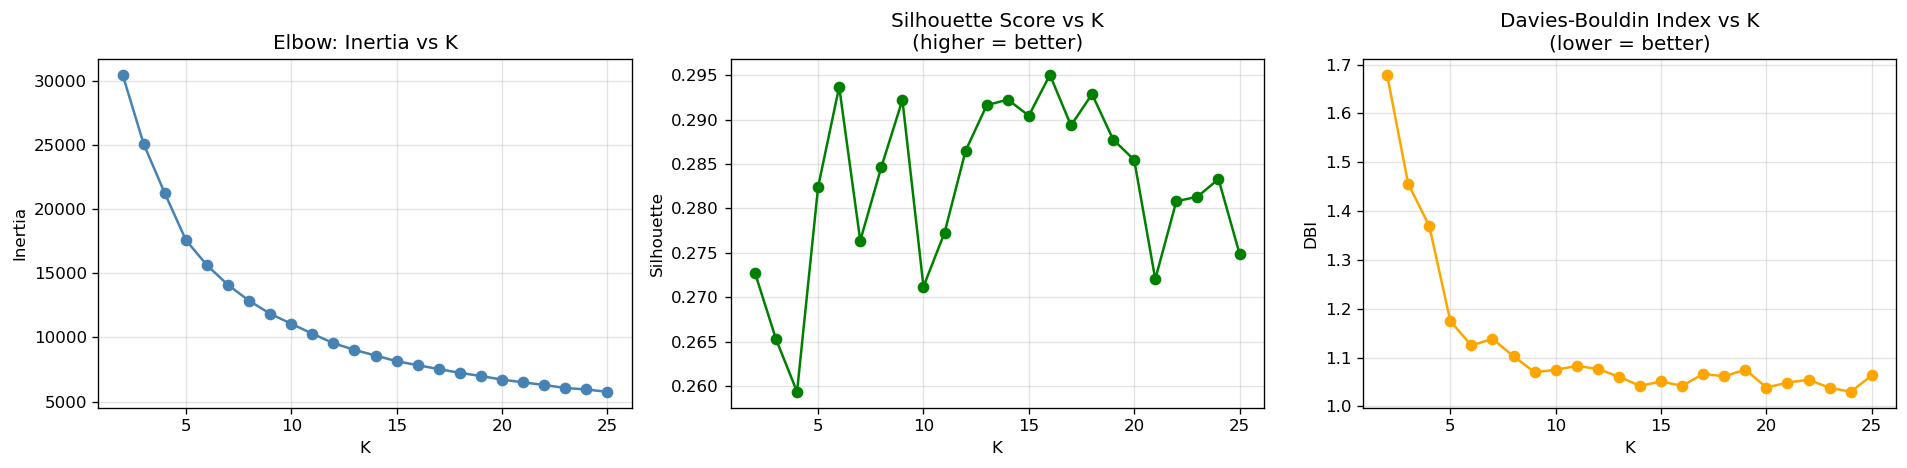

Auto-selected K = 16  (highest silhouette = 0.2950)
Override K below if the elbow plot suggests a different value


In [5]:
k_range     = range(2, 26)
inertias    = []
silhouettes = []
dbi_scores  = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=RANDOM_STATE))
    dbi_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow: Inertia vs K")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.35)

axes[1].plot(k_range, silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette Score vs K\n(higher = better)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.35)

axes[2].plot(k_range, dbi_scores, marker="o", color="orange")
axes[2].set_title("Davies-Bouldin Index vs K\n(lower = better)")
axes[2].set_xlabel("K"); axes[2].set_ylabel("DBI")
axes[2].grid(alpha=0.35)

plt.tight_layout()
plt.savefig("figures/kmeans_elbow.png", bbox_inches="tight")
plt.show()

K_BEST = silhouettes.index(max(silhouettes)) + 2  
print(f"Auto-selected K = {K_BEST}  (highest silhouette = {max(silhouettes):.4f})")
print("Override K below if the elbow plot suggests a different value")

## Run K-Means with Chosen K

K = 16
  Inertia          : 7,838.1
  Silhouette score : 0.2950  (target > 0.3)
  Davies-Bouldin   : 1.0420  (lower is better)


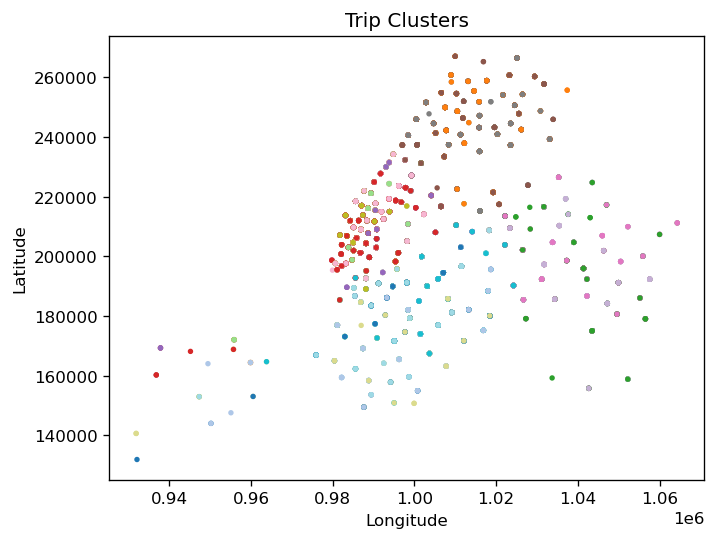

In [6]:
K = K_BEST  

km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df_train["kmeans_cluster"] = km.fit_predict(X)

sil_km  = silhouette_score(X, df_train["kmeans_cluster"], sample_size=min(5000, len(X)), random_state=RANDOM_STATE)
dbi_km  = davies_bouldin_score(X, df_train["kmeans_cluster"])
inertia = km.inertia_

print(f"K = {K}")
print(f"  Inertia          : {inertia:,.1f}")
print(f"  Silhouette score : {sil_km:.4f}  (target > 0.3)")
print(f"  Davies-Bouldin   : {dbi_km:.4f}  (lower is better)")

# Plot Trip Clusters
plt.scatter(df_train["pickup_lon"], df_train["pickup_lat"], c=df_train["kmeans_cluster"], s=5, cmap="tab20")
plt.title("Trip Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Cluster Size Distribution & Emissions Profile

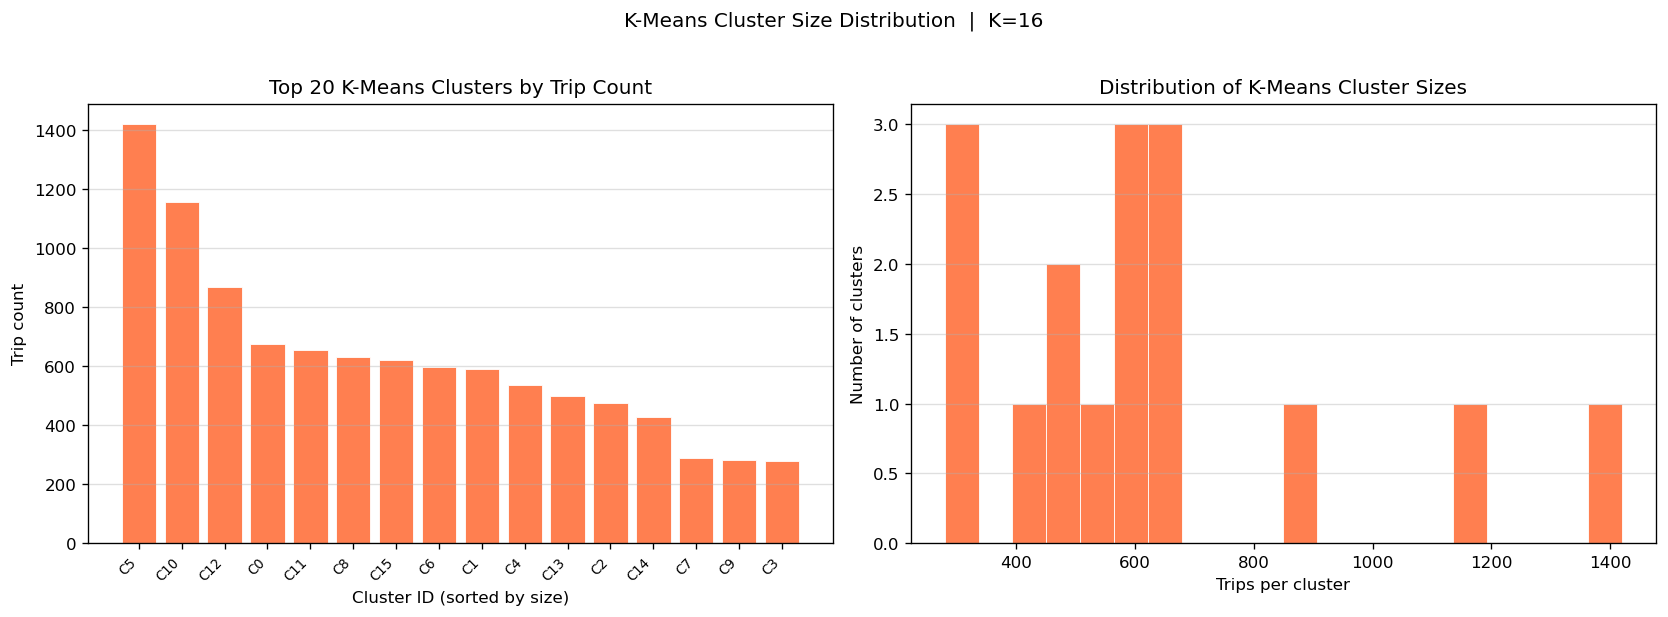

Median cluster size : 593 trips
Largest cluster     : 1420 trips
Smallest cluster    : 280 trips
Std dev of sizes    : 306.9  (lower = more balanced)


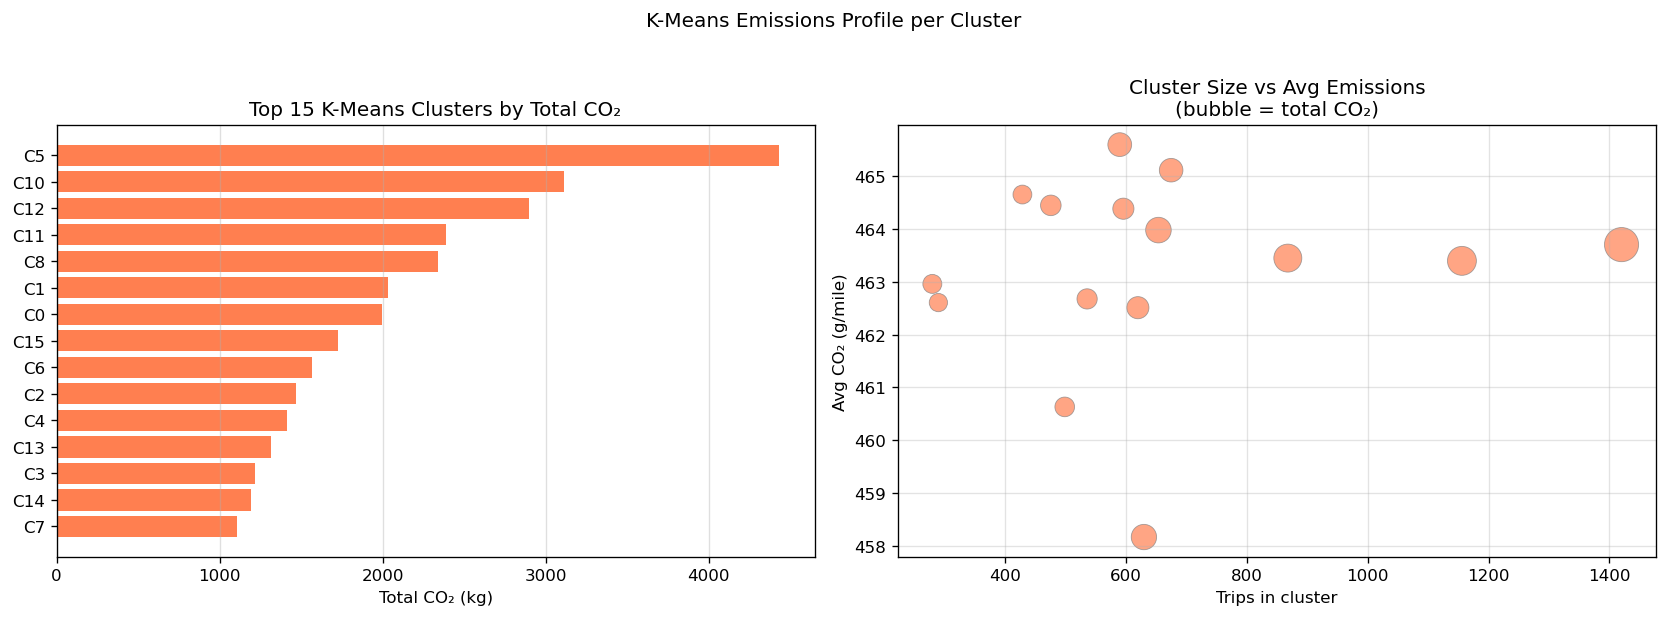


Top 5 highest-emission K-Means clusters:
 kmeans_cluster  n_trips  avg_co2_g_mi  total_co2_kg  avg_trip_miles
              5     1420    463.701081   4428.517631        6.713523
             10     1156    463.393751   3114.813828        5.814450
             12      868    463.445831   2897.717177        7.218609
             11      654    463.975531   2390.305057        7.842485
              8      630    458.167893   2338.643762        8.080041


In [7]:
cluster_sizes = (
    df_train.groupby("kmeans_cluster").size()
    .reset_index(name="n_trips")
    .sort_values("n_trips", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-20 clusters by size
top20 = cluster_sizes.head(20)
axes[0].bar(top20.index, top20["n_trips"], color="coral", edgecolor="white", linewidth=0.5)
axes[0].set_xticks(top20.index)
axes[0].set_xticklabels([f"C{int(c)}" for c in top20["kmeans_cluster"]], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Cluster ID (sorted by size)")
axes[0].set_ylabel("Trip count")
axes[0].set_title("Top 20 K-Means Clusters by Trip Count")
axes[0].grid(axis="y", alpha=0.4)

# Histogram of all cluster sizes
axes[1].hist(cluster_sizes["n_trips"], bins=20, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Trips per cluster")
axes[1].set_ylabel("Number of clusters")
axes[1].set_title("Distribution of K-Means Cluster Sizes")
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle(f"K-Means Cluster Size Distribution  |  K={K}", y=1.02)
plt.tight_layout()
plt.savefig("figures/kmeans_cluster_sizes.png", bbox_inches="tight")
plt.show()

print(f"Median cluster size : {cluster_sizes['n_trips'].median():.0f} trips")
print(f"Largest cluster     : {cluster_sizes['n_trips'].max()} trips")
print(f"Smallest cluster    : {cluster_sizes['n_trips'].min()} trips")
print(f"Std dev of sizes    : {cluster_sizes['n_trips'].std():.1f}  (lower = more balanced)")

# CO₂ emissions by cluster (top 15) 
emissions_km = (
    df_train.groupby("kmeans_cluster")
    .agg(
        n_trips        = ("trip_miles",     "count"),
        avg_co2_g_mi   = ("co2TailpipeGpm", "mean"),
        total_co2_kg   = ("co2_total_g",    lambda x: x.sum() / 1000),
        avg_trip_miles = ("trip_miles",     "mean"),
    )
    .reset_index()
    .sort_values("total_co2_kg", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(
    [f"C{int(r['kmeans_cluster'])}" for _, r in emissions_km.iterrows()],
    emissions_km["total_co2_kg"], color="coral"
)
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("Top 15 K-Means Clusters by Total CO₂")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.4)

axes[1].scatter(
    emissions_km["n_trips"], emissions_km["avg_co2_g_mi"],
    s=emissions_km["total_co2_kg"] / emissions_km["total_co2_kg"].max() * 400 + 20,
    color="coral", alpha=0.7, edgecolors="grey", linewidth=0.5
)
axes[1].set_xlabel("Trips in cluster")
axes[1].set_ylabel("Avg CO₂ (g/mile)")
axes[1].set_title("Cluster Size vs Avg Emissions\n(bubble = total CO₂)")
axes[1].grid(alpha=0.35)

plt.suptitle("K-Means Emissions Profile per Cluster", y=1.02)
plt.tight_layout()
plt.savefig("figures/kmeans_emissions_profile.png", bbox_inches="tight")
plt.show()

print("\nTop 5 highest-emission K-Means clusters:")
print(emissions_km[["kmeans_cluster","n_trips","avg_co2_g_mi","total_co2_kg","avg_trip_miles"]].head().to_string(index=False))

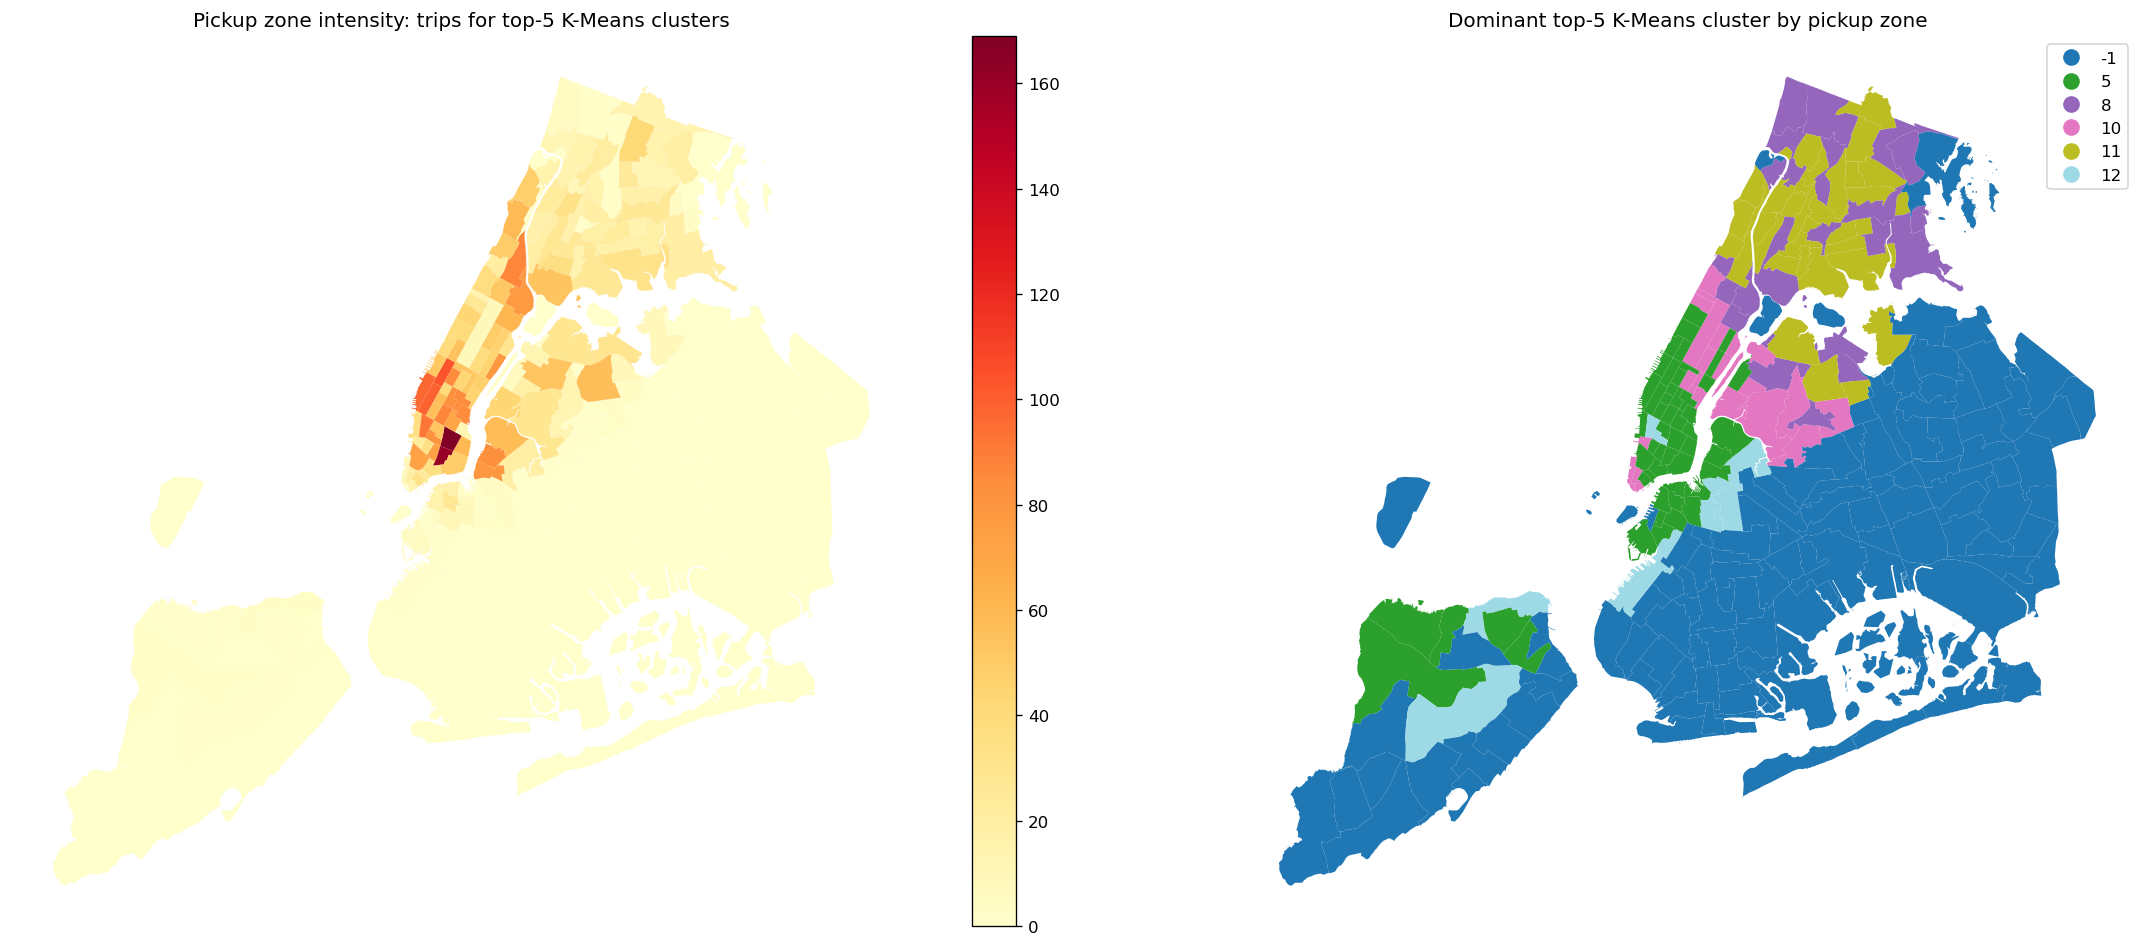

In [9]:
# Geographic breakdown for top 5 K-Means clusters (same style as Hierarchical / EDA)
import geopandas as gpd
zones = gpd.read_file("../Data/raw/taxi_zones/taxi_zones.shp")

high_impact_clusters_km = emissions_km.head(5)["kmeans_cluster"].tolist()
agg_zone_km = (
    df_train[df_train["kmeans_cluster"].isin(high_impact_clusters_km)]
    .groupby("PULocationID")
    .agg(
        trips=("kmeans_cluster", "count"),
        top_cluster=("kmeans_cluster", lambda x: x.value_counts().idxmax()),
        total_co2_kg=("co2_total_g", lambda x: x.sum() / 1000),
    )
    .reset_index()
)

agg_zone_km.columns = ["LocationID", "trips", "top_cluster", "total_co2_kg"]
zone_map_km = zones.merge(agg_zone_km, on="LocationID", how="left")
zone_map_km["trips"] = zone_map_km["trips"].fillna(0)
zone_map_km["top_cluster"] = zone_map_km["top_cluster"].fillna(-1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

zone_map_km.plot(
    column="trips",
    cmap="YlOrRd",
    legend=True,
    ax=axes[0],
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "no data"},
)
axes[0].set_title("Pickup zone intensity: trips for top-5 K-Means clusters")
axes[0].axis("off")

zone_map_km.plot(
    column="top_cluster",
    cmap="tab20",
    legend=True,
    ax=axes[1],
    categorical=True,
    missing_kwds={"color": "lightgrey"},
)
axes[1].set_title("Dominant top-5 K-Means cluster by pickup zone")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
df_train.to_csv("../Data/generated/trips_kmeans_labeled.csv", index=False)
print(f"Saved trips_kmeans_labeled.csv ({len(df_train):,} rows)")

Saved trips_kmeans_labeled.csv (10,000 rows)


## KMeans Validation

In [23]:
RANDOM_STATE_VAL = 23
df_validate = preprocess(df_full.sample(n = SUBSET_N, random_state = RANDOM_STATE_VAL).reset_index(drop=True))
X_val = scaler.transform(df_validate[features].values)
km = KMeans(n_clusters=K, random_state=RANDOM_STATE_VAL, n_init=10)
df_validate["kmeans_cluster"] = km.fit_predict(X_val)
sil_km  = silhouette_score(X_val, df_validate["kmeans_cluster"], sample_size=min(5000, len(X_val)), random_state=RANDOM_STATE_VAL)
dbi_km  = davies_bouldin_score(X_val, df_validate["kmeans_cluster"])
inertia = km.inertia_
print(f"K = {K}")
print(f"  Inertia          : {inertia:,.1f}")
print(f"  Silhouette score : {sil_km:.4f}  (target > 0.3)")
print(f"  Davies-Bouldin   : {dbi_km:.4f}  (lower is better)")

Working subset after cleaning: 10,000 rows
K = 16
  Inertia          : 7,960.0
  Silhouette score : 0.2794  (target > 0.3)
  Davies-Bouldin   : 1.0366  (lower is better)


## K-Means Clustering Results (K = 16)

### Trained Model Results

| Metric               | Value   | Notes                |
|----------------------|---------|----------------------|
| Inertia              | 7,838.1 | Lower is better      |
| Silhouette Score     | 0.2950  | Target > 0.30        |
| Davies-Bouldin Index | 1.0420  | Lower is better      |

### Validation Model Results

| Metric               | Value   | Notes                |
|----------------------|---------|----------------------|
| Inertia              | 7,960.0 | Lower is better      |
| Silhouette Score     | 0.2794  | Target > 0.30        |
| Davies-Bouldin Index | 1.0366  | Lower is better      |


The trained and validation models produce similar results across all evaluation metrics, indicating that the model generalizes well to unseen data. The inertia increases slightly in the validation set, which is expected due to differences in data distribution, while the silhouette score shows only a minor decrease (0.2950 to 0.2794), suggesting that cluster cohesion and separation remain stable. The Davies-Bouldin Index values are low and consistent, indicating relatively compact and well-separated clusters. Overall, K = 16 provides a stable clustering solution, though there may be room for improvement in cluster separation.